<a href="https://colab.research.google.com/github/maanaav15369/CNN-/blob/main/transfer_learning_feature_extraction(data_augmentation)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

In [2]:
os.environ["KAGGLE_API_TOKEN"] = "KGAT_cce1ea9efb0b3e8ca5a889fa3b0c2ecf"

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets download -d maanaavtrivedi/cat-dog

Dataset URL: https://www.kaggle.com/datasets/maanaavtrivedi/cat-dog
License(s): CC0-1.0
100% 1.06G/1.06G [00:10<00:00, 109MB/s]



In [5]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cat-dog.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [7]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [9]:
conv_base.trainable = False

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [13]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/test',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 275ms/step - accuracy: 0.8681 - loss: 0.3128 - val_accuracy: 0.8944 - val_loss: 0.2414
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.8987 - loss: 0.2400 - val_accuracy: 0.9110 - val_loss: 0.2118
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 264ms/step - accuracy: 0.9054 - loss: 0.2216 - val_accuracy: 0.9146 - val_loss: 0.2037
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.9090 - loss: 0.2140 - val_accuracy: 0.9188 - val_loss: 0.2003
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 271ms/step - accuracy: 0.9135 - loss: 0.2024 - val_accuracy: 0.9130 - val_loss: 0.2100
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 268ms/step - accuracy: 0.9179 - loss: 0.1932 - val_accuracy: 0.9202 - val_loss: 0.1925
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.9219 - loss: 0.1864 - val_accuracy: 0.9186 - val_loss: 0.1877
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 268ms/step - accuracy: 0.9237 -

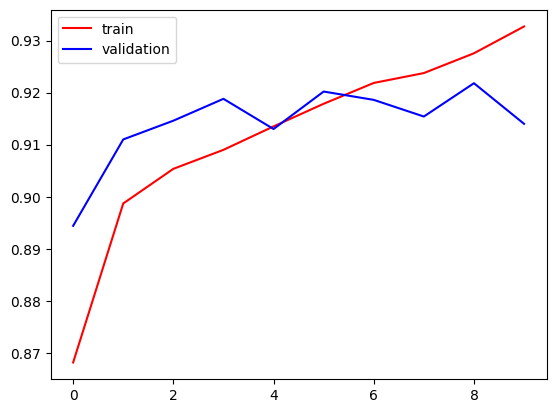

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

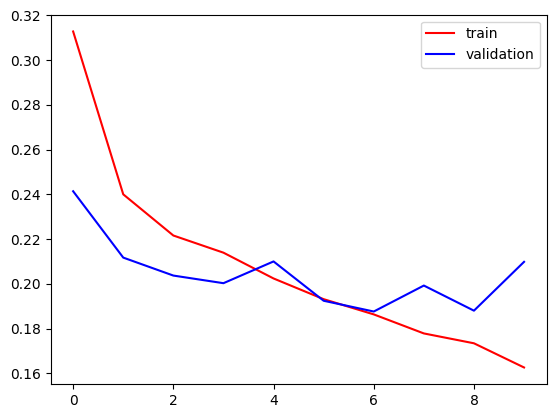

In [18]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
# Using data augmentation ,the overfitting is reduced...